In [1]:
# LOAD PACKAGES 
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
opj = os.path.join
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats as stats
from prfpy_csenf.stimulus import *
from prfpy_csenf.model import Iso2DGaussianModel,Norm_Iso2DGaussianModel
# SCOTOMA PROJECT 
from artscot_JOV.load_saved_info import *
from artscot_JOV.plot_functions import *
from artscot_JOV.prfpy_functions import *
from artscot_JOV.prfpy_ts_plotter import *
# Fix seed (just in case doing anything random)
np.random.seed(0)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Could not find FS_LICENSE, set using os.environ above


In [2]:
# OUTPUT DIRECTORY
fig_output = './figures'
os.makedirs(fig_output, exist_ok=True)
as_cols = {
    'AS0'   : '#000000',
    'AS1'   : '#d95f02',
    'AS2'   : '#7570b3',
}

# Load subjects - sped up by multiprocessing
ecc_bins = np.linspace(0,5,6)
# More IP plotting functions

mod_cols = {
    'gauss' : '#3CA969',
    'G' : '#3CA969',
    'norm' :  '#8557A7',
    'N' :  '#8557A7',
}

Making folder


<IPython.core.display.Javascript object>

tried to do ctrl+s from here - did not work. remember to save before running...
jupyter nbconvert --to html /data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/code/artscot_JOV/analysis/r0_reports/artscot_plots.ipynb --output /data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/derivatives/notebook_timeline/scot_MAIN-2026-03-02/artscot_plots.html


[NbConvertApp] Converting notebook /data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/code/artscot_JOV/analysis/r0_reports/artscot_plots.ipynb to html
[NbConvertApp] Writing 451450 bytes to /data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/derivatives/notebook_timeline/scot_MAIN-2026-03-02/artscot_plots.html


jupyter nbconvert --to html /data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/code/artscot_JOV/analysis/r0_reports/artscot_plots.ipynb --no-input --output /data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/derivatives/notebook_timeline/scot_MAIN-2026-03-02/artscot_plots_NOCODE.html


[NbConvertApp] Converting notebook /data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/code/artscot_JOV/analysis/r0_reports/artscot_plots.ipynb to html
[NbConvertApp] Writing 276839 bytes to /data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/derivatives/notebook_timeline/scot_MAIN-2026-03-02/artscot_plots_NOCODE.html


## LOAD

#### Where and what to load

In [3]:
task_list = ['AS0', 'AS1', 'AS2']
look_in = '/data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/derivatives/prf_for_pub'

model_list = ['gauss' , 'norm']
sub_list = ['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05', 'sub-06', 'sub-07'] 

roi_fit = 'all'
roi_list = ['all', 'v1custom', 'v2custom', 'v3custom', 'v3abcustom', 'v4custom', 'LOcustom', 'TOcustom', 'IPScustom']



In [4]:
# # Add info to publicly available data
# for sub in sub_list:
#     roi_dict = {}
#     for roi in roi_list:
#         roi_dict[roi] = get_roi_FS(sub, roi, combine_matches=True)
#         f = opj(look_in, sub, f'{sub}_roi.npz')
#         np.savez(f, **roi_dict)


## statistics functions
Calculate how much data is upsampled from bold to surface 
This will be used to determine how we do the subsampling

In [5]:
import nibabel as nib
from dpu_mini.fs_tools import *
def calculate_sub_vol2surf_upsample(sub, fs_dir, bold_voxel_volume):
            
    # 1. Load anatomical segmentation (FreeSurfer's aseg.nii.gz)
    aseg = nib.load(opj(fs_dir, sub, 'mri', 'aseg.mgz')) #, 'aseg.nii.gz'))

    
    # 2. Calculate volume of ONE anatomical voxel (in mm³)
    anat_vox_vol = (aseg.header.get_zooms()[0] *  # voxel size in x
                    aseg.header.get_zooms()[1] *  # voxel size in y  
                    aseg.header.get_zooms()[2])   # voxel size in z

    # 3. Calculate total cortex volume (in mm³)
    # Label 42 = right cortex, Label 3 = left cortex in FreeSurfer
    cortex_volume = ((aseg.get_fdata() == 42).sum() + (aseg.get_fdata() == 3).sum()) *  \
          anat_vox_vol 
    # 4. Estimate number of BOLD voxels that cover the cortex
    # (bold_voxel_volume must be defined earlier in their code)
    nr_bold_voxels = cortex_volume / bold_voxel_volume

    # 5. Get actual number of surface vertices
    nr_surf_vertices = np.sum(dag_load_nverts(sub, fs_dir)) # Add left and right
    # 6. Calculate upsampling factor
    us_factor = nr_surf_vertices / nr_bold_voxels
    return us_factor
# fs_dir = opj(derivatives_dir, 'freesurfer')
# # Bold voxel volume = 1.7**3 
# for sub in sub_list: 
#     us_factor = calculate_sub_vol2surf_upsample(sub, fs_dir, 1.7**3)
#     print(us_factor)
#     f = opj(look_in, sub, f'{sub}_us_factor.npy')
#     np.save(f, us_factor)

def get_us_factor(sub):
    f = opj(look_in, sub, f'{sub}_us_factor.npy')
    return np.load(f)

In [6]:
def cortical_permutation_test(
    a,b, subsample_fraction,
    n_subsamples= 10000,
    alternative= 'two-sided',
    random_seed = None
):
    """
    Permutation test for paired cortical surface data with spatial subsampling.
    
    This method addresses spatial autocorrelation by:
    1. Randomly subsampling vertices (to decorrelate spatially)
    2. Performing a sign-flip permutation test on each subsample
    3. Aggregating results across subsamples
    
    The p-value represents the proportion of subsamples where a randomly 
    sign-flipped null distribution produces a mean as extreme as the observed mean.
    
    Parameters
    ----------
    a : np.ndarray, shape (n_vertices,)
        Parameter values for condition A
    b : np.ndarray, shape (n_vertices,)
        Parameter values for condition B (same vertices as A)
    subsample_fraction : float, default=0.01
        Fraction of vertices to randomly sample in each iteration.
        Should be small enough that sampled vertices are spatially decorrelated.
        Typical values: 0.01 (1%) to 0.05 (5%)
    n_subsamples : int, default=10000
        Number of random subsamples to test.
        More subsamples = more stable p-value estimate.
    alternative : {'two-sided', 'greater', 'less'}, default='two-sided'
        - 'two-sided': test if A ≠ B
        - 'greater': test if A > B
        - 'less': test if A < B
    random_seed : int, optional
        Random seed for reproducibility
        
    Returns
    -------
    results : dict
        - 'pvalue': proportion of subsamples where null was as extreme as observed
        - 'mean_difference': average difference (A - B) across subsamples
        - 'std_difference': standard deviation of differences across subsamples
        - 'subsample_means': array of mean differences for each subsample
        - 'effect_size': mean_difference / std_difference (similar to Cohen's d)
    
    Follows Aqil et al., 2019
    """
    if random_seed is not None:
        np.random.seed(random_seed)
    
    # Validate inputs
    if len(a) != len(b):
        raise ValueError("a and b must have same length")
    
    n_vertices = len(a)
    n_subsample = max(1, int(n_vertices * subsample_fraction))
    
    
    # Precompute differences
    diff = a - b
    
    # Run subsampling permutation test
    subsample_means = np.zeros(n_subsamples)
    null_more_extreme = np.zeros(n_subsamples, dtype=bool)
    
    for i in range(n_subsamples):
        # Randomly subsample vertices
        subsample_idx = np.random.randint(0, n_vertices, size=n_subsample)
        diff_sub = diff[subsample_idx]
        
        # Compute observed weighted mean difference
        observed_mean = np.mean(diff_sub)
        subsample_means[i] = observed_mean
        
        # Generate ONE null sample by randomly flipping signs
        # Under H0 (no difference), sign of each vertex's difference is arbitrary
        random_signs = np.sign(np.random.rand(n_subsample) - 0.5)
        null_diff = random_signs * diff_sub
        null_mean = np.mean(null_diff)
        
        # Check if null is as extreme as observed
        if alternative == 'two-sided':
            null_more_extreme[i] = np.abs(null_mean) >= np.abs(observed_mean)
        elif alternative == 'greater':
            null_more_extreme[i] = null_mean >= observed_mean
        elif alternative == 'less':
            null_more_extreme[i] = null_mean <= observed_mean
        else:
            raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")
    
    # Compute final p-value
    pvalue = np.mean(null_more_extreme)
    
    # Compute effect size (standardized mean difference)
    mean_diff = np.mean(subsample_means)
    std_diff = np.std(subsample_means)
    effect_size = mean_diff / std_diff if std_diff > 0 else 0
    
    return {
        'pvalue': pvalue,
        'mean_difference': mean_diff,
        'std_difference': std_diff,
        'subsample_means': subsample_means,
        'effect_size': effect_size,
        'n_subsample_vertices': n_subsample,
        'n_subsamples': n_subsamples,
        'subsample_fraction': subsample_fraction
    }


#### Load stimuli

In [7]:
scotoma_info = get_scotoma_info(sub_list[0])
dm_npy = get_design_matrix_npy(['AS0', 'AS1', 'AS2'])
fit_settings = load_data_prf(
    sub_list[0], 'AS0', 'gauss', var_to_load='settings',
    look_in=look_in, 
    )['AS0']['gauss']
prfpy_stim = {}
prfpy_mod = {'gauss':{}, 'norm':{}}
cut_vols = 5
for stim in dm_npy.keys():
    prfpy_stim[stim] = PRFStimulus2D(
        screen_size_cm=fit_settings['screen_size_cm'],
        screen_distance_cm=fit_settings['screen_distance_cm'],
        design_matrix=dm_npy[stim][:,:,cut_vols:], 
        axis=0,
        TR=fit_settings['TR']
        )
    prfpy_mod['gauss'][stim] = Iso2DGaussianModel(prfpy_stim[stim])
    prfpy_mod['norm'][stim] = Norm_Iso2DGaussianModel(prfpy_stim[stim])



task-AS0
/data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/derivatives/prf_for_pub/sub-01/ses-1/sub-01_model-gauss_roi-all_task-AS0-fits_stage-iter_constr-tc_desc-prf_params.pkl


In [8]:
def simplify_prf_names(prf_name):
    prf_out = prf_name.replace('gauss', 'G')
    prf_out = prf_out.replace('norm', 'N')
    prf_out = prf_out.replace('_', 'f_') # 
    return prf_out


#### Load the fits

In [9]:
from joblib import Parallel, delayed

# --- Parallel Processing Setup ---
# takes ages to load each subject 
# Define the function that processes a single subject
def process_subject(sub, task_list, look_in, model_list, roi_fit, prfpy_mod):
    """
    Function that encapsulates the original loop body for one subject.
    Returns the key (subject) and the value (PrfMulti object) for the final dictionary.
    """
    
    # 1. Load Time-Course (TC) data
    real_tc = load_data_tc(
        sub=sub,
        task_list=task_list,
        look_in=look_in
    )
    
    # 2. Load PRF Parameters
    prf_pars = load_data_prf(
        sub=sub,
        task_list=task_list,
        look_in=look_in,
        model_list=model_list,
        roi_fit=roi_fit,
        include='tc',
    )
    
    # 3. Create TSPlotter objects (Inner loop - Keep sequential for simplicity/overhead)
    prf_obj_list = []
    prf_id_list = []
    for iT, task in enumerate(task_list):
        dm_task = task.split('_')[0]
        for model in model_list:
            prf_obj_list.append(TSPlotter(
                prf_params = prf_pars[task][model],
                model=model,
                prfpy_model=prfpy_mod[model][dm_task],
                real_ts=real_tc[task],
            ))
            prf_id_list.append(
                simplify_prf_names(f'{task}_{model}'))

    # 4. Create the PrfMulti object
    subject_prf_multi = PrfMulti(
        prf_obj_list,
        prf_id_list,
    )
    
    return sub, subject_prf_multi

# --- Execute Parallelization ---

print("Starting parallel processing...")
results = Parallel(n_jobs=7, verbose=10)(
    delayed(process_subject)(
        sub, 
        task_list, 
        look_in, 
        model_list, 
        roi_fit, 
        prfpy_mod
    )
    for sub in sub_list
)
print("Parallel processing complete.")

# 5. Reassemble the final dictionary from the results
prf_obj = dict(results)

Starting parallel processing...


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.


Could not find FS_LICENSE, set using os.environ above
Could not find FS_LICENSE, set using os.environ above
Could not find FS_LICENSE, set using os.environ above
Could not find FS_LICENSE, set using os.environ above
Could not find FS_LICENSE, set using os.environ above
Could not find FS_LICENSE, set using os.environ above
Could not find FS_LICENSE, set using os.environ above
/data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/derivatives/prf_for_pub/sub-07/ses-1/sub-07_model-gauss_roi-all_task-AS0-fits_stage-iter_constr-tc_desc-prf_params.pkl
/data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/derivatives/prf_for_pub/sub-05/ses-1/sub-05_model-gauss_roi-all_task-AS0-fits_stage-iter_constr-tc_desc-prf_params.pkl
/data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/derivatives/prf_for_pub/sub-03/ses-1/sub-03_model-gauss_roi-all_task-AS0-fits_stage-iter_constr-tc_desc-prf_params.pkl
/data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/derivatives/p

/data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/code/artscot_JOV/analysis/artscot_JOV/prfpy_functions.py:296: RuntimeWarning: invalid value encountered in divide
  self.params_dd['size_ratio'] = self.params_dd['size_2'] / self.params_dd['size_1']
/data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/code/artscot_JOV/analysis/artscot_JOV/prfpy_functions.py:297: RuntimeWarning: invalid value encountered in divide
  self.params_dd['amp_ratio'] = self.params_dd['amp_2'] / self.params_dd['amp_1']
/data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/code/artscot_JOV/analysis/artscot_JOV/prfpy_functions.py:299: RuntimeWarning: invalid value encountered in divide
  self.params_dd['bd_ratio'] = self.params_dd['b_val'] / self.params_dd['d_val']
/data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/code/artscot_JOV/analysis/artscot_JOV/prfpy_functions.py:301: RuntimeWarning: invalid value encountered in divide
  self.params_dd['sup_idx'] = (self.params_d

prf_params.shape[-1]=8
include hrf = True
include rsq = True
/data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/derivatives/prf_for_pub/sub-04/ses-1/sub-04_model-norm_roi-all_task-AS2-fits_stage-iter_constr-tc_desc-prf_params.pkl
prf_params.shape[-1]=12
include hrf = True
include rsq = True
prf_params.shape[-1]=8
include hrf = True
include rsq = True
/data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/derivatives/prf_for_pub/sub-01/ses-1/sub-01_model-norm_roi-all_task-AS1-fits_stage-iter_constr-tc_desc-prf_params.pkl
prf_params.shape[-1]=8
include hrf = True
include rsq = True
prf_params.shape[-1]=12
include hrf = True
include rsq = True
prf_params.shape[-1]=12
include hrf = True
include rsq = True


...

[Parallel(n_jobs=7)]: Done   3 out of   7 | elapsed:  3.1min remaining:  4.1min
/data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/code/artscot_JOV/analysis/artscot_JOV/prfpy_functions.py:296: RuntimeWarning: invalid value encountered in divide
  self.params_dd['size_ratio'] = self.params_dd['size_2'] / self.params_dd['size_1']
/data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/code/artscot_JOV/analysis/artscot_JOV/prfpy_functions.py:297: RuntimeWarning: invalid value encountered in divide
  self.params_dd['amp_ratio'] = self.params_dd['amp_2'] / self.params_dd['amp_1']
/data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/code/artscot_JOV/analysis/artscot_JOV/prfpy_functions.py:299: RuntimeWarning: invalid value encountered in divide
  self.params_dd['bd_ratio'] = self.params_dd['b_val'] / self.params_dd['d_val']
/data1/projects/dumoulinlab/Lab_members/Marcus/projects/pilot1/code/artscot_JOV/analysis/artscot_JOV/prfpy_functions.py:301: RuntimeWarning: 

prf_params.shape[-1]=8
include hrf = True
include rsq = True
prf_params.shape[-1]=12
include hrf = True
include rsq = True
prf_params.shape[-1]=8
include hrf = True
include rsq = True
prf_params.shape[-1]=12
include hrf = True
include rsq = True


[Parallel(n_jobs=7)]: Done   4 out of   7 | elapsed:  3.2min remaining:  2.4min
[Parallel(n_jobs=7)]: Done   5 out of   7 | elapsed:  3.4min remaining:  1.3min


Parallel processing complete.


[Parallel(n_jobs=7)]: Done   7 out of   7 | elapsed:  3.8min finished


# Timeseries plots

In [10]:
def ts_plot(sub, task2, idx):
    # [1] Load the timeseries
    ts_data = {}
    ts_data['AS0'] = prf_obj[sub].prf_obj[f'AS0f_G'].real_ts[idx,:]
    ts_data[task2] = prf_obj[sub].prf_obj[f'{task2}f_G'].real_ts[idx,:]

    # PRINT RELEVANT INFO!!!
    for task in ['AS0', task2]:
        for model in ['G', 'N']:
            this_rsq = prf_obj[sub].prf_obj[f'{task}f_{model}'].pd_params['rsq'][idx]
            this_ecc = prf_obj[sub].prf_obj[f'{task}f_{model}'].pd_params['ecc'][idx]
            print(f'{sub} - {task} - {model}: {idx} - rsq = {this_rsq:.2f} - ecc = {this_ecc:.2f}')
    # [2] Predicted time series
    ts_pred = {}
    for task in ['AS0', task2]:
        for model in ['G', 'N']:
            ts_pred[f'{task}_{model}'] = prf_obj[sub].prf_obj[f'{task}f_{model}'].return_preds(idx).squeeze()

    # [3] Positions of the prfs
    prf_pos = {}
    for task in ['AS0', task2]:
        for model in ['G', 'N']:
            prf_pos[f'{task}_{model}'] = [
                prf_obj[sub].pd_params[f'{task}f_{model}-x'].iloc[idx],
                prf_obj[sub].pd_params[f'{task}f_{model}-y'].iloc[idx],
            ]
    # [4] Set up the plot
    w_ratios = [4, 3]

    w_val = 15 # (w_ratios[0] + w_ratios[1]) * fig_fact
    h_val =  7.5# w_ratios[1] * fig_fact
    fig, ax = plt.subplots(2, 2,gridspec_kw={'width_ratios': w_ratios})
    fig.set_size_inches(w_val, h_val)
    fig.subplots_adjust(wspace=.5, hspace=.5)
    fig.suptitle(f'{sub} - {task2} - {idx}', fontsize=20)
    # fig.supt
    ts_x = np.arange(ts_data['AS0'].shape[-1]) * prf_obj[sub].prf_obj['AS0f_G'].TR_in_s
    lw = {'G' : 5, 'N' : 2.5}
    alpha = {'G' : .5, 'N' : 1}
    # Plot the data 
    for iT,task in enumerate(['AS0', task2]):
        ax[iT,0].plot(
            ts_x, ts_data[task], 
            ':^', color='k', markersize=5, lw=2, alpha=.5,
            label='data',
            )
        # Plot the predictions
        for model in ['G', 'N']:
            ax[iT,0].plot(
                ts_x, ts_pred[f'{task}_{model}'], 
                '-', markersize=10, 
                lw=lw[model], 
                alpha=alpha[model],
                color=mod_cols[model], 
                label=model,
                )
        
        
        
        ax[iT,0].set_title(task)
        ax[iT,0].set_xlabel('Time (s)')
        ax[iT,0].set_ylabel('BOLD signal')
        ax[iT,0].set_xlim([0, ts_x[-1]])
        ax[iT,0].legend()

    # Add the arrows
    arr_mask = np.zeros(prf_obj[sub].pd_params.shape[0], dtype=bool)
    arr_mask[idx] = True
    for iM,model in enumerate(['G', 'N']):
        prf_obj[sub].arrow(
            f'AS0f_{model}', f'{task2}f_{model}', th={'roi': arr_mask}, 
            ax=ax[iM,1], 
            arrow_col='k', # mod_cols[model],
            # arrow_width=.05, 
            # arrow_headwidth= 1, 
            dot_alpha=1, 
            # add_grid_lines=False,
            ecc_bounds=np.linspace(0,5,4),
            vf_line_width=1,
            vf_line_alpha=.3,
            # old_col='g', new_col='r',
            # do_scatter=True, 
        )
        ax[iM,1].scatter(
            x=prf_pos[f'AS0_{model}'][0],  
            y=prf_pos[f'AS0_{model}'][1],
            marker='o',  
            color=mod_cols[model], s=100, alpha=1, 
            label='AS0',
            )
        ax[iM,1].scatter(
            x=prf_pos[f'{task2}_{model}'][0],  
            y=prf_pos[f'{task2}_{model}'][1],
            marker='o', facecolors='none',  
            color=mod_cols[model], s=100, alpha=1, 
            label='AS0',
            )        
            
        scot_patch = mpl.patches.Circle(
            scotoma_info[f'task-{task2}']['scotoma_centre'], 
            scotoma_info[f'task-{task2}']['scotoma_radius'], 
            color='grey', linewidth=4, 
            fill=False, alpha=1,
            linestyle='--', 
            label='Scotoma'
            )
        ax[iM,1].add_patch(scot_patch)



    plt.tight_layout()
    return


### TS eg. 1

sub-05 - AS0 - G: 818 - rsq = 0.80 - ecc = 2.37
sub-05 - AS0 - N: 818 - rsq = 0.80 - ecc = 2.23
sub-05 - AS2 - G: 818 - rsq = 0.70 - ecc = 3.63
sub-05 - AS2 - N: 818 - rsq = 0.73 - ecc = 2.52


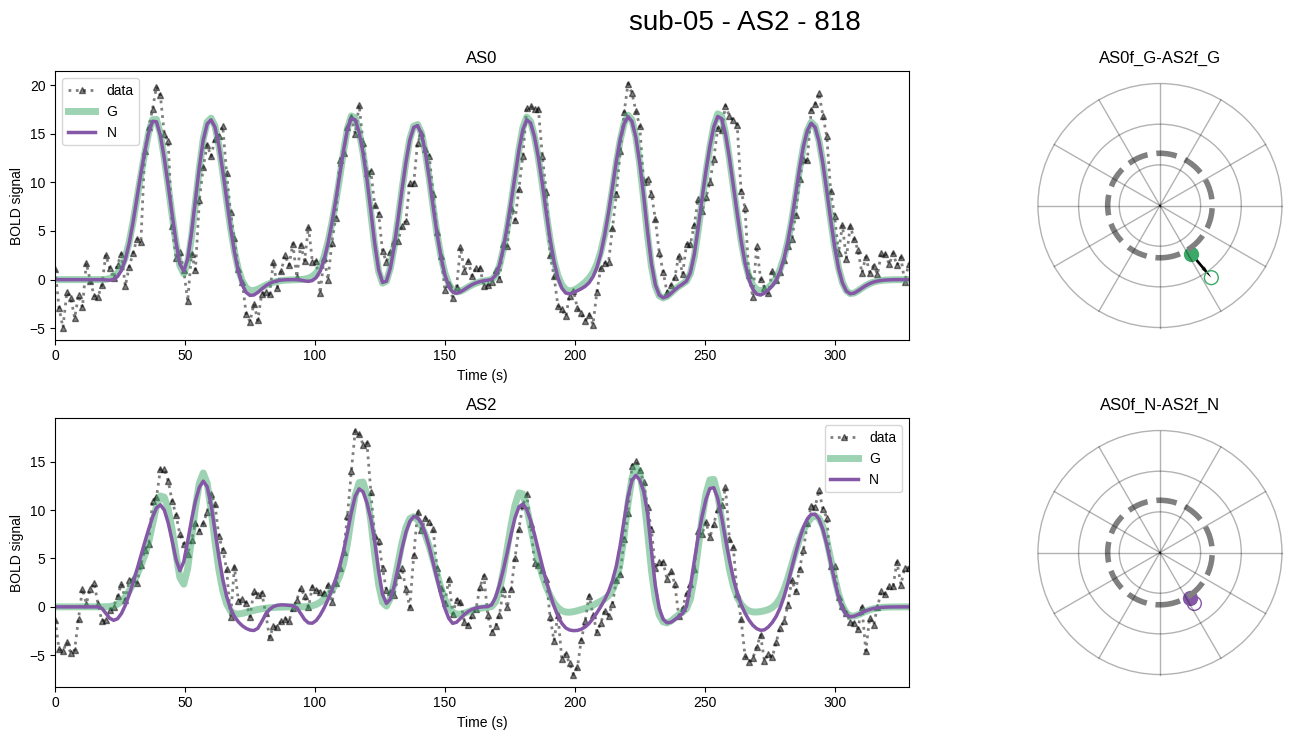

In [11]:
%matplotlib inline

ts_plot('sub-05', 'AS2', 818) 
plt.gcf().savefig(opj(fig_output, 'ts_plot_eg2.png'), bbox_inches='tight', dpi=150)


# Vector plots

/home/daghlian/.conda/envs/scot_001/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/daghlian/.conda/envs/scot_001/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


2755

v1custom
Mean shift G=0.2832, N=0.269
STD shift G=0.2460, N=0.207
{'pvalue': np.float64(0.023), 'mean_difference': np.float64(0.014575103192616777), 'std_difference': np.float64(0.005126406834191518), 'subsample_means': array([0.01488218, 0.00942465, 0.01060503, ..., 0.01002741, 0.00678041,
       0.01025084], shape=(10000,)), 'effect_size': np.float64(2.843142119623716), 'n_subsample_vertices': 505, 'n_subsamples': 10000, 'subsample_fraction': np.float64(0.18365141628124138)}
1896

v3abcustom
Mean shift G=1.0007, N=0.743
STD shift G=0.9196, N=0.728
{'pvalue': np.float64(0.0), 'mean_difference': np.float64(0.2571684659457167), 'std_difference': np.float64(0.030904500795865566), 'subsample_means': array([0.26105116, 0.2382146 , 0.23417743, ..., 0.24888131, 0.31384874,
       0.24946786], shape=(10000,)), 'effect_size': np.float64(8.321392008380894), 'n_subsample_vertices': 348, 'n_subsamples': 10000, 'subsample_fraction': np.float64(0.18365141628124138)}
Inserting info into svg fi

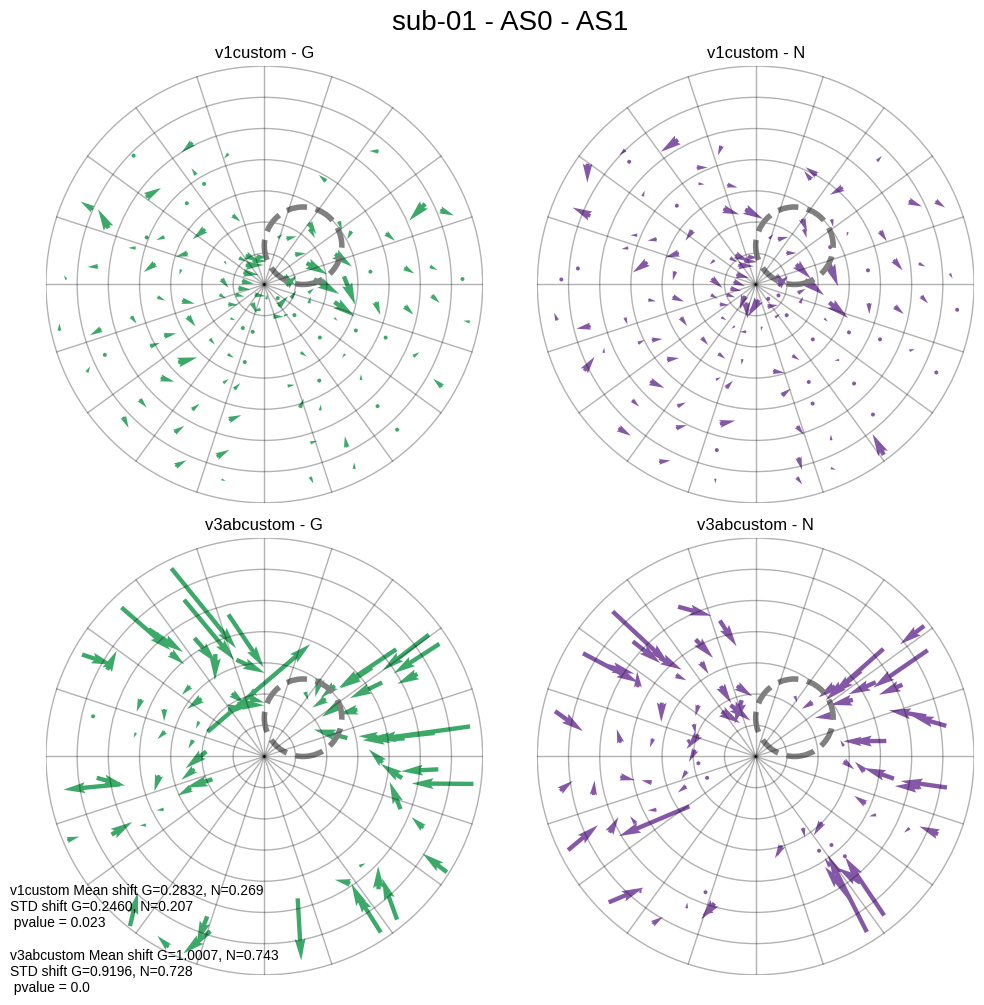

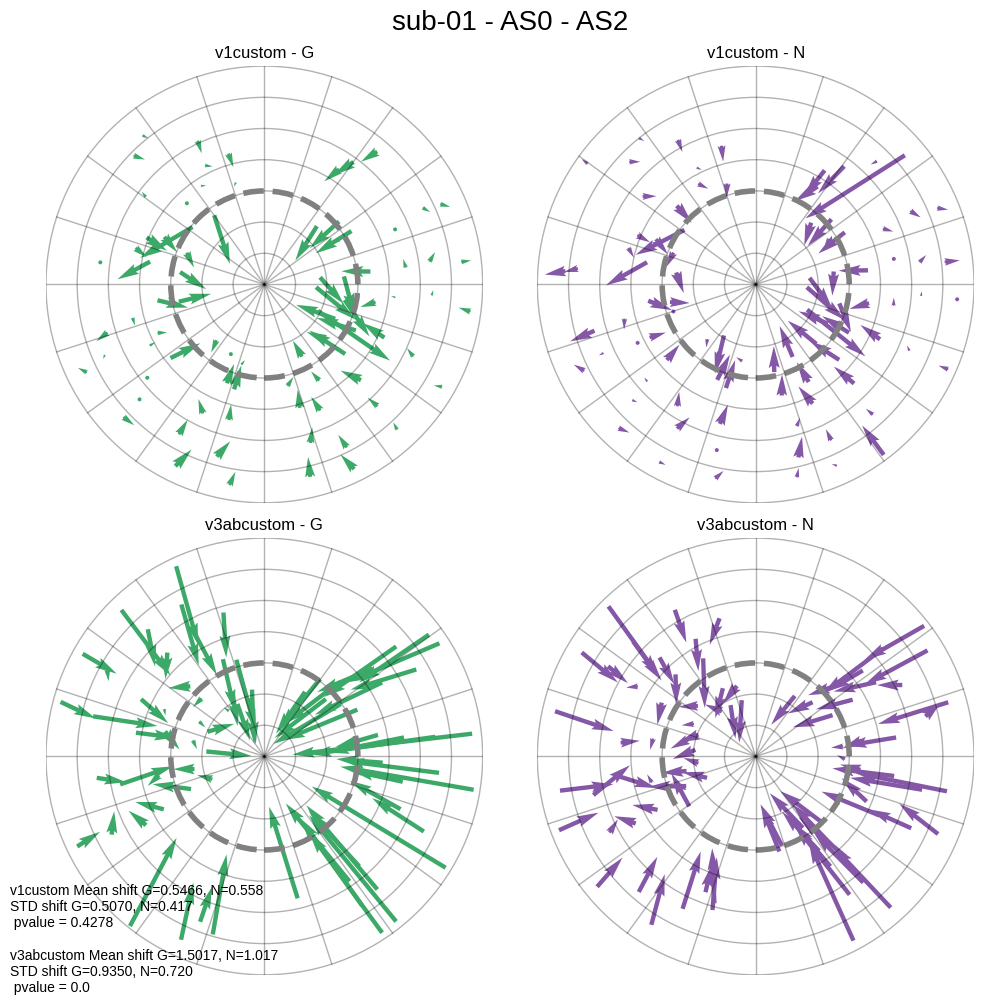

In [12]:
# EVERYTHING 
%matplotlib inline
min_rsq = 0.3
max_ecc = 5
min_vx = 100
sub = 'sub-01'
task1 = 'AS0'
for task2 in ['AS1', 'AS2']:

    fig, axs = plt.subplots(2,2, figsize=(10,10))
    fig.suptitle(f'{sub} - {task1} - {task2}', fontsize=20)

    full_ecc_bounds =  np.linspace(0, 4, 5)
    full_pol_bounds = np.linspace(-np.pi, np.pi, 13)

    v_rois = ['v1custom', 'v3abcustom']
    v_models = ['G', 'N']
    arrow_bin_kwargs = dict(
        do_binning=True, 
        ecc_bounds = np.linspace(0, 5, 8),
        pol_bounds = np.linspace(-np.pi, np.pi, 21),
        min_vx_per_bin=min_vx, 
    )
    scat_options = dict(
        do_arrows=True, 
        do_scatter = False,
    )
    ctext_note = ''
    for iR,roi in enumerate(v_rois):
        for iM,model in enumerate(v_models):
            ax = axs[iR,iM]

            ax.set_ylim(-5,5)
            ax.set_xlim(-5,5)
            th = {
                
                f'{task1}f_{model}-min-rsq': min_rsq,
                f'{task2}f_{model}-min-rsq': min_rsq,
                f'{task1}f_{model}-max-ecc': max_ecc,
                f'{task2}f_{model}-max-ecc': max_ecc,
                'roi' : get_roi(sub, roi, combine_matches=True),
            }
            prf_obj[sub].arrow(
                ax = ax,
                pold=f'{task1}f_{model}',
                pnew=f'{task2}f_{model}',         
                th=th,
                dot_size=25,
                old_col = 'k',
                new_col = 'r',
                dot_alpha=1,
                arrow_col=mod_cols[model],
                **scat_options,
                **arrow_bin_kwargs,
                arrow_headwidth = 2.5
            )
            scot_patch = mpl.patches.Circle(
                scotoma_info[f'task-{task2}']['scotoma_centre'], 
                scotoma_info[f'task-{task2}']['scotoma_radius'], 
                color='grey', linewidth=4, 
                fill=False, alpha=1,
                linestyle='--', 
                label='Scotoma'
                )
            
            ax.add_patch(scot_patch)
            ax.set_title(f'{roi} - {model}')

        # **** Add info about the mean, STD, and t testing...
        th = {        
            f'{task1}f_G-min-rsq': 0.1,
            f'{task2}f_G-min-rsq': 0.1,
            f'{task1}f_G-max-ecc': max_ecc,
            f'{task2}f_G-max-ecc': max_ecc,
            f'{task1}f_N-min-rsq': 0.1,
            f'{task2}f_N-min-rsq': 0.1,
            f'{task1}f_N-max-ecc': max_ecc,
            f'{task2}f_N-max-ecc': max_ecc,        
            'roi' : get_roi(sub, roi, combine_matches=True),
        }    
        vx_mask  = prf_obj[sub].return_vx_mask(th)
        vx_mask &= get_roi(sub, roi, combine_matches=True) # ALL                 
        print(vx_mask.sum())
        if vx_mask.sum()<min_vx:
            # print(f'failed to get {roi} for {sub}')        
            continue
        shift1s = prf_obj[sub].return_diff_params(
            f'{task1}f_G', f'{task2}f_G', 'shift_mag')['shift_mag'][vx_mask].to_numpy()
        shift2s = prf_obj[sub].return_diff_params(
            f'{task1}f_N', f'{task2}f_N', 'shift_mag')['shift_mag'][vx_mask].to_numpy()  
        diff_stats = cortical_permutation_test(
            shift1s, shift2s, subsample_fraction=1/get_us_factor(sub), 
            n_subsamples=10000, alternative='two-sided', random_seed=0
        )
        print(f'')
        print(f'{roi}')
        print(f'Mean shift G={np.mean(shift1s):.4f}, N={np.mean(shift2s):.3f}')
        print(f'STD shift G={np.std(shift1s):.4f}, N={np.std(shift2s):.3f}')   
        print(diff_stats)      
        # bloop
        ctext_note += f'\n\n{roi} ' + \
            f'Mean shift G={np.mean(shift1s):.4f}, N={np.mean(shift2s):.3f}\n' + \
            f'STD shift G={np.std(shift1s):.4f}, N={np.std(shift2s):.3f}\n ' + \
            f'pvalue = {diff_stats["pvalue"]}'


            # ***
    plt.tight_layout()
    plt.gcf().savefig(opj(fig_output, f'vector_plot{sub}_{task1}_{task2}.png'), bbox_inches='tight', dpi=150)

# Paired bar

In [13]:
from dpu_mini.stats import dag_paired_ttest
def PAIRED_df(prf_obj, roi_list, p1diff, p2diff, diff_ids,  **kwargs):
    # HOW THRESH...
    # only_close_to_scot = kwargs.get('only_close_to_scot', False)
    min_rsq = kwargs.get('min_rsq', 0.1)
    max_ecc = kwargs.get('max_ecc', 5)
    min_vx = kwargs.get('min_vx', 50)

    sub_list = list(prf_obj.keys())
    nice_roi_list = [i.split('custom')[0] for i in roi_list]

    # Create threshold dictionary    
    th = {}
    for th_key in [*p1diff, *p2diff]:
        th[f'{th_key}-min-rsq'] = min_rsq
        th[f'{th_key}-max-ecc'] = max_ecc    

    # Difference
    diff_stats = {}
    diff_dict = {
        'sub' : [],
        'roi' : [],
        'condition' : [],
        'shift' : [],
    }
    diff_vxwise = {}
    for iS,sub in enumerate(sub_list):
        diff_vxwise[sub] = {}
        diff_stats[sub] = {}
        vx_mask  = prf_obj[sub].return_vx_mask(th)
        for iR, roi in enumerate(roi_list):
            nice_roi = nice_roi_list[iR]
            vx_mask  = prf_obj[sub].return_vx_mask(th)
            vx_mask &= get_roi_FS(sub, roi, combine_matches=True) # ALL                 
            if vx_mask.sum()<min_vx:
                # print(f'failed to get {roi} for {sub}')        
                continue
            shift1s = prf_obj[sub].return_diff_params(
                p1diff[0], p1diff[1], 'shift_mag')['shift_mag'][vx_mask].to_numpy()
            shift1 = np.median(shift1s)
            shift2s = prf_obj[sub].return_diff_params(
                p2diff[0], p2diff[1], 'shift_mag')['shift_mag'][vx_mask].to_numpy()
            shift2 = np.median(shift2s)
            diff_stats[sub][nice_roi] = cortical_permutation_test(
                shift1s, shift2s, subsample_fraction=1/get_us_factor(sub), 
                n_subsamples=10000, alternative='two-sided', random_seed=0
            )
            diff_vxwise[sub][roi] = {
                'vx_mask' : vx_mask, 
                diff_ids[0]: shift1s, 
                diff_ids[1]: shift2s, 
            }
            # Do the stats
            # diff_stats[sub][nice_roi] = dag_paired_ttest(shift1s, shift2s, upsampling_factor=upsampling_factor)
            # shift 1
            diff_dict['sub'].append(sub)
            diff_dict['roi'].append(nice_roi)
            diff_dict['condition'].append(diff_ids[0])
            diff_dict['shift'].append(shift1)
            # shift 2
            diff_dict['sub'].append(sub)
            diff_dict['roi'].append(nice_roi)
            diff_dict['condition'].append(diff_ids[1])
            diff_dict['shift'].append(shift2)
            
    df = pd.DataFrame(diff_dict)
    return df, diff_vxwise, diff_stats


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def SCOT_paired_bar_plot(df, diff_stats, fig, ax, nice_roi_list, mod_cols):
    
    # Calculate medians
    rois = df['roi'].unique()
    roi_medians = {'gauss':[], 'norm':[]}
    for condition in ['gauss', 'norm']:
        for roi in rois:
            roi_data = df[(df['roi'] == roi) & (df['condition'] == condition)]['shift']
            roi_medians[condition].append(roi_data.mean())

    # Plotting the median bars
    width = 0.35
    bar_positions = np.arange(len(rois))

    for i, condition in enumerate(['gauss', 'norm']):
        bar_offset = width * i
        ax.bar(bar_positions + bar_offset, roi_medians[condition], width=width, label=condition, color=mod_cols[condition])

    # Plotting the individual participant lines
    participants = df['sub'].unique()
    sub_cols = plt.cm.tab20(np.linspace(0, 1, len(participants)))
    for iS,participant in enumerate(participants):
        for iR,roi in enumerate(rois):
            gauss_value = df[(df['sub'] == participant) & (df['roi'] == roi) & (df['condition'] == 'gauss')]['shift'] #.values[0]
            norm_value = df[(df['sub'] == participant) & (df['roi'] == roi) & (df['condition'] == 'norm')]['shift'] # .values[0]
            if len(gauss_value) == 0:
                continue
            if diff_stats[participant][roi]['pvalue'] > 0.001:
                lkwargs = {
                    'alpha' : 0.8,
                    'linestyle' : '--',
                    'marker' : 'o',
                    'mfc' : 'none',
                    'markersize' : 4,
                }
            else:
                lkwargs = {
                    'alpha' : 1,
                    'linestyle' : '-',
                    'marker' : 'x',
                    'markersize' : 5,
                }
            x_values = [bar_positions[iR] , bar_positions[iR] + width]            
            y_values = [gauss_value, norm_value]
            # PRINT THE STUFF TOO!
            print(f'{participant} - {roi} - gshift={gauss_value.values[0]:.9f} - nshift={norm_value.values[0]:.9f}, pvalue={diff_stats[participant][roi]["pvalue"]:.9f}')
            ax.plot(x_values, y_values, 
                    color='grey', # sub_cols[iS], # 'grey', 
                    **lkwargs,
                    # label=participant if iR == 0 else None
                    )
    # Customize plot
    ax.set_xticks(bar_positions + width / 2)
    ax.set_xticklabels(nice_roi_list)
    ax.set_ylim([0, 2.25])
    ax.set_xlabel('ROI')
    ax.set_ylabel('Shift magnitude (degrees)')
    ax.set_title('')
    ax.legend(title='Model')
    sns.despine()
    # plt.show()
    return fig,ax


def SCOT_diff_bar_plot(df, diff_stats, fig, ax, nice_roi_list, mod_cols):

    # Calculate medians
    rois = df['roi'].unique()
    roi_medians = []
    for roi in rois:
        mdata = []
        for condition in ['gauss', 'norm']:
            roi_data = df[(df['roi'] == roi) & (df['condition'] == condition)]['shift']
            mdata.append(roi_data.mean())
        roi_medians.append(mdata[0] - mdata[1])

    # Plotting the median bars
    width = 0.35 * 2
    bar_positions = np.arange(len(rois))
    ax.bar(bar_positions, roi_medians, width=width, color='#fdbb84') # label=condition, color=mod_cols[condition])

    # Plotting the individual participant lines
    participants = df['sub'].unique()
    sub_cols = plt.cm.tab20(np.linspace(0, 1, len(participants)))
    for iS,participant in enumerate(participants):
        for iR,roi in enumerate(rois):
            gauss_value = df[(df['sub'] == participant) & (df['roi'] == roi) & (df['condition'] == 'gauss')]['shift'].to_numpy() #.values[0]
            norm_value = df[(df['sub'] == participant) & (df['roi'] == roi) & (df['condition'] == 'norm')]['shift'].to_numpy() # .values[0]            
            if len(gauss_value) == 0:
                continue
                                
            diff_value = gauss_value.copy() - norm_value.copy()
            if diff_stats[participant][roi]['pvalue'] > 0.001:
                lkwargs = {
                    'alpha' : 0.8,
                    'marker' : 'o',
                    'facecolors' : 'none',
                    's' : 15,
                }
            else:
                lkwargs = {
                    'alpha' : 1,
                    'marker' : 'x',
                    's' : 20,
                }
            ax.scatter(
                bar_positions[iR], diff_value, 
                color='grey', 
                **lkwargs,
                )

    # Customize plot
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(nice_roi_list)
    sns.despine()
    ax.set_ylim([-.2, 1])
    ax.set_yticks([-.2, 0, .2, .4, .6, .8, 1])
    xlim = ax.get_xlim()
    ax.hlines(0, -1, len(rois), linestyle='--', alpha=.5)
    ax.set_xlim(xlim)
    
    # ax.set_xlabel('ROI')
    # ax.set_ylabel('Shift magnitude (degrees)')
    # ax.set_title('')
    # ax.legend(title='Model')

    # plt.show()
    return fig,ax

#### Across ROIs


TASK!! AS1
sub-01 - v1 - gshift=0.229094661 - nshift=0.228718651, pvalue=0.023000000
sub-01 - v2 - gshift=0.294437562 - nshift=0.285917093, pvalue=0.311400000
sub-01 - v3 - gshift=0.253249456 - nshift=0.250456844, pvalue=0.444300000
sub-01 - v3ab - gshift=0.696060795 - nshift=0.493014659, pvalue=0.000000000
sub-01 - v4 - gshift=0.522268480 - nshift=0.451495399, pvalue=0.001500000
sub-01 - LO - gshift=0.520365671 - nshift=0.480591546, pvalue=0.000000000
sub-01 - TO - gshift=1.355033559 - nshift=0.875700448, pvalue=0.000000000
sub-01 - IPS - gshift=1.002134589 - nshift=0.853083154, pvalue=0.000000000
sub-02 - v1 - gshift=0.284829276 - nshift=0.289124027, pvalue=0.368400000
sub-02 - v2 - gshift=0.364588478 - nshift=0.362996568, pvalue=0.247500000
sub-02 - v3 - gshift=0.408230608 - nshift=0.406270018, pvalue=0.108100000
sub-02 - v3ab - gshift=0.730120406 - nshift=0.650140739, pvalue=0.130000000
sub-02 - v4 - gshift=0.540870896 - nshift=0.536332147, pvalue=0.219800000
sub-02 - LO - gshift=

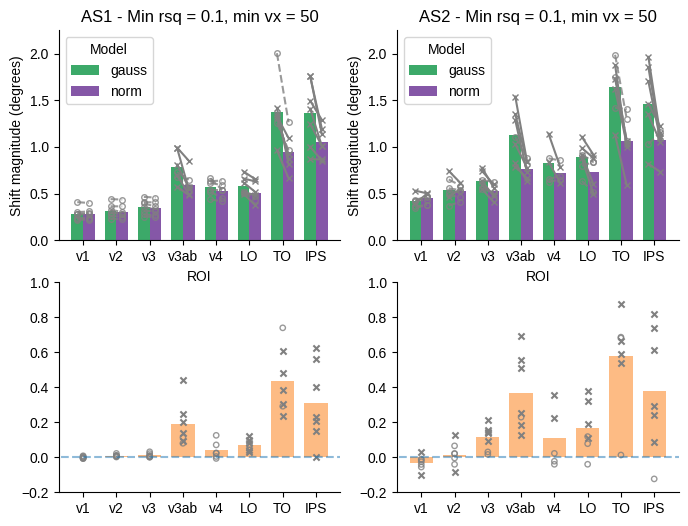

In [15]:
%matplotlib inline
min_rsq = 0.1
min_vx = 50
max_ecc = 5
df_task = {}
fig, axs = plt.subplots(2, 2, figsize=(8,6))
for iT,task in enumerate(['AS1', 'AS2']):    
    print('')
    print(f'TASK!! {task}')
    df, _, diff_stats = PAIRED_df(
        prf_obj=prf_obj,
        roi_list=roi_list[1::],
        min_rsq=min_rsq,
        max_ecc=max_ecc,
        min_vx = min_vx,
        p1diff=['AS0f_G',    f'{task}f_G'],
        p2diff=['AS0f_N',    f'{task}f_N'],
        diff_ids = ['gauss', 'norm'],
    )
    df_task[task] = df.copy()
    ax = axs[0,iT]
    fig, ax = SCOT_paired_bar_plot(
        df=df, diff_stats=diff_stats, fig=fig, ax=ax,
        nice_roi_list=[i.split('custom')[0] for i in roi_list[1::]],
        mod_cols=mod_cols
        )
    ax.set_title(f'{task} - Min rsq = {min_rsq}, min vx = {min_vx}')
    ax = axs[1,iT]
    fig, ax = SCOT_diff_bar_plot(
        df=df, diff_stats=diff_stats, fig=fig, ax=ax,
        nice_roi_list=[i.split('custom')[0] for i in roi_list[1::]],
        mod_cols=mod_cols
        )
    
    # ax.set_title(f'{task} - Min rsq = {min_rsq}, min vx = {min_vx}')
    # ax.set_ylim([0, 2])
    # sns.despine()

    # Difference plot



# STATS 

In [34]:
%matplotlib inline
min_rsq = 0.1
min_vx = 50
max_ecc = 5
df_task = {}
dvx_task = {}
for iT,task in enumerate(['AS1', 'AS2']):    
    print('')
    print(f'TASK!! {task}')
    df, df_vxwise, diff_stats = PAIRED_df(
        prf_obj=prf_obj,
        roi_list=roi_list[1::],
        min_rsq=min_rsq,
        max_ecc=max_ecc,
        min_vx = min_vx,
        p1diff=['AS0f_G',    f'{task}f_G'],
        p2diff=['AS0f_N',    f'{task}f_N'],
        diff_ids = ['gauss', 'norm'],
    )
    df_task[task] = df.copy()
    dvx_task[task] = df_vxwise.copy()
 


TASK!! AS1

TASK!! AS2


In [33]:

for sub in sub_list:
    results = {
        'roi' : [], 
        'task' : [], 
        'shiftg' : [], 
        'shiftn' : [], 
        'pvalue' : [], 
    }
    for t in ['AS1', 'AS2']:
        for roi in roi_list[1::]:
            if roi not in dvx_task[t][sub].keys():
                continue
            a = dvx_task[t][sub][roi]['gauss'].copy()
            b = dvx_task[t][sub][roi]['norm'].copy()
            tr = cortical_permutation_test(
                a=a,
                b=b,
                subsample_fraction=0.1,
                n_subsamples=10000,
                alternative='two-sided',
                random_seed=123
            )
            results['roi'].append(roi)
            results['task'].append(t)
            results['shiftg'].append(a.mean())
            results['shiftn'].append(b.mean())
            results['pvalue'].append(tr['pvalue'])
    print(f'{sub}')
    results = pd.DataFrame(results)
    print(results)
    print('')
    

sub-01
           roi task    shiftg    shiftn  pvalue
0     v1custom  AS1  0.283164  0.268610  0.0957
1     v2custom  AS1  0.347023  0.338718  0.3876
2     v3custom  AS1  0.312381  0.308396  0.4773
3   v3abcustom  AS1  1.000699  0.743413  0.0000
4     v4custom  AS1  0.631215  0.534914  0.0205
5     LOcustom  AS1  0.739120  0.641027  0.0036
6     TOcustom  AS1  1.586125  1.246715  0.0002
7    IPScustom  AS1  1.192258  0.968436  0.0000
8     v1custom  AS2  0.546600  0.557721  0.4514
9     v2custom  AS2  0.600584  0.586014  0.4126
10    v3custom  AS2  0.606022  0.471186  0.0000
11  v3abcustom  AS2  1.501739  1.017285  0.0000
12    v4custom  AS2  1.051347  0.768685  0.0002
13    LOcustom  AS2  1.468159  1.119500  0.0000
14    TOcustom  AS2  1.902796  1.407770  0.0000
15   IPScustom  AS2  1.218519  0.972712  0.0000

sub-02
           roi task    shiftg    shiftn  pvalue
0     v1custom  AS1  0.343178  0.337998  0.4624
1     v2custom  AS1  0.421373  0.410131  0.4103
2     v3custom  AS1  0.49

In [31]:
from statsmodels.stats.multitest import multipletests

for task in df_task.keys():
    df = df_task[task]
    results = []

    for roi in df['roi'].unique():
        roi_data = df[df['roi'] == roi]
        gauss_values = roi_data[roi_data['condition'] == 'gauss']['shift'].values
        norm_values = roi_data[roi_data['condition'] == 'norm']['shift'].values
        
        t_stat, p_value = stats.ttest_rel(gauss_values, norm_values, alternative='two-sided')
        results.append({
            'roi': roi,
            't_statistic': t_stat,
            'p_value': p_value
        })

    # Convert to DataFrame
    results_df = pd.DataFrame(results)

    # --- MULTIPLE COMPARISON CORRECTION ---
    # 'fdr_bh' is the Benjamini-Hochberg procedure (False Discovery Rate)
    # 'bonferroni' is a more conservative alternative
    reject, pvals_corrected, _, _ = multipletests(results_df['p_value'], 
                                                  alpha=0.05, 
                                                  method='fdr_bh')
    
    results_df['p_corrected'] = pvals_corrected
    results_df['significant'] = reject
    results_df.to_csv(f'z_{task}')
    print(f'***********TASK = {task}***********')
    print(results_df)

# Nonlinearities over roi

In [19]:
def nonlinearity_plot(df, k, fig, ax, nice_roi_list):

    # Calculate medians
    rois = df['roi'].unique()
    roi_medians = []
    for roi in rois:
        mdata = []
        roi_data = df[(df['roi'] == roi)][k]
        roi_medians.append(roi_data.mean())

    # Plotting the median bars
    width = 0.35 * 2
    bar_positions = np.arange(len(rois))
    ax.bar(bar_positions, roi_medians, width=width, color='#fdbb84') # label=condition, color=mod_cols[condition])

    # Plotting the individual participant lines
    participants = df['sub'].unique()
    for iS,participant in enumerate(participants):
        for iR,roi in enumerate(rois):
            k_value = df[(df['sub'] == participant) & (df['roi'] == roi)][k].to_numpy() #.values[0]          
            if len(k_value) == 0:
                continue
     
            lkwargs = {
                'alpha' : 0.8,
                'marker' : 'o',
                'facecolors' : 'none',
                's' : 15,
            }
            ax.scatter(
                bar_positions[iR], k_value, 
                color='grey', 
                **lkwargs,
                )

    # Customize plot
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(nice_roi_list)
    sns.despine()
    # ax.set_ylim([-.2, 1])
    # ax.set_yticks([-.2, 0, .2, .4, .6, .8, 1])
    xlim = ax.get_xlim()
    # ax.hlines(0, -1, len(rois), linestyle='--', alpha=.5)
    ax.set_xlim(xlim)
    
    # ax.set_xlabel('ROI')
    # ax.set_ylabel('Shift magnitude (degrees)')
    # ax.set_title('')
    # ax.legend(title='Model')

    # plt.show()
    return fig,ax


In [20]:
mpar_dict = {
    'sub' : [],
    'roi' : [], 
    'amp_1' : [], 
    'amp_2' : [], 
    'size_1': [], 
    'size_2': [], 
    'size_ratio': [], 
    'amp_ratio': [], 
    'bd_ratio':[], 
    'b_val' : [], 
    'd_val' : [], 
}
%matplotlib inline
min_rsq = 0.1
min_vx = 50
max_ecc = 5
for sub in sub_list:
    for iR,roi in enumerate(roi_list[1:]):
        roi_mask = get_roi(sub, roi, combine_matches=True)
        th = {
            'min-rsq':0.1,
            'max-ecc':5.0, 
            'roi':roi_mask,
        }
        vx_mask = prf_obj[sub].prf_obj['AS0f_N'].return_vx_mask(th=th)
        if vx_mask.sum()<min_vx:
            continue
        tpd = prf_obj[sub].prf_obj['AS0f_N'].pd_params.iloc[vx_mask,:].copy()
        for k in mpar_dict.keys():
            if k =='roi' :
                mpar_dict[k].append(roi)
            elif k == 'sub':
                mpar_dict[k].append(sub)
            else:
                mpar_dict[k].append(
                    tpd[k].to_numpy().mean()
                )


mpar_pd = pd.DataFrame(mpar_dict)

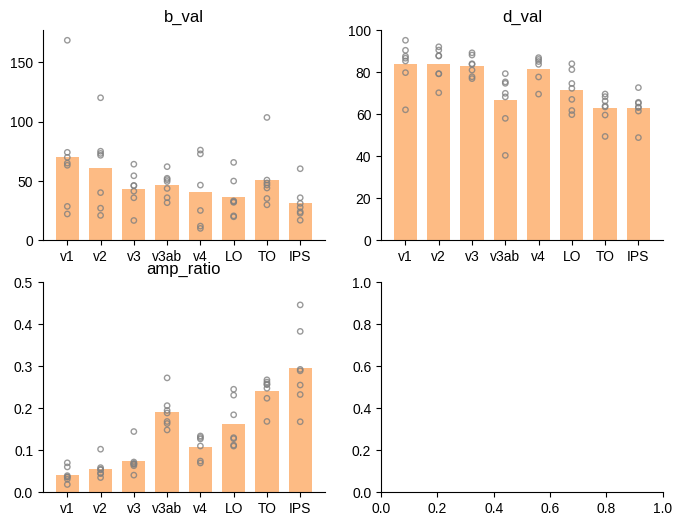

In [21]:
# fig,axs = plt.subplots(1,3, figsize=(15,5
fig, axs = plt.subplots(2, 2, figsize=(8,6))
axs = axs.flatten()
for i,k in enumerate(['b_val', 'd_val', 'amp_ratio']):
    nonlinearity_plot(
        df=mpar_pd, k=k, fig=fig, ax=axs[i], nice_roi_list=[i.split('custom')[0] for i in roi_list[1::]],
    )
    if k == 'amp_ratio':
        axs[i].set_ylim(0, 0.5)
    axs[i].set_title(k)



fig.savefig(opj(fig_output, 'param_roi_plot.png'), bbox_inches='tight', dpi=150)

### AS0-N parameters correlation with 1G-pRF shifts

In [92]:

%matplotlib inline
min_rsq = 0.1
min_vx = 50
max_ecc = 5
mparcorr_pd = {}
for task in ['AS1', 'AS2']:
    mparcorr_dict= {
        'sub' : [],
        'roi' : [], 
        'amp_1' : [], 
        'amp_2' : [], 
        'size_1': [], 
        'size_2': [], 
        'size_ratio': [], 
        'amp_ratio': [], 
        'bd_ratio':[], 
        'b_val' : [], 
        'd_val' : [], 
        '1Gshift': [],
        'DNshift': [], 
        'dshift': [],
    }
    for sub in sub_list:
        for iR,roi in enumerate(roi_list[1:]):

            roi_mask = get_roi(sub, roi, combine_matches=True)
            th = {
                'AS0f_N-min-rsq':0.1,
                'AS0f_N-max-ecc':5.0, 
                'AS0f_G-min-rsq':0.1, 
                'AS0f_G-max-ecc':5.0,
                f'{task}f_G-min-rsq':0.1,
                f'{task}f_G-max-ecc':5.0,
                'roi':roi_mask,
            }

            thN = {
                'AS0f_N-min-rsq':0.1,
                'AS0f_N-max-ecc':5.0, 
                'roi':roi_mask,
            }
            vx_mask = prf_obj[sub].return_vx_mask(th=th)
            
            if vx_mask.sum()<min_vx:
                continue
            vx_mask_n =  prf_obj[sub].return_vx_mask(th=thN)
            tpd = prf_obj[sub].prf_obj['AS0f_N'].pd_params.iloc[vx_mask_n,:].copy()
            shift1gs = prf_obj[sub].return_diff_params(
                'AS0f_G', f'{task}f_G', 'shift_mag')['shift_mag'][vx_mask].to_numpy().mean()
            shiftdns = prf_obj[sub].return_diff_params(
                'AS0f_N', f'{task}f_N', 'shift_mag')['shift_mag'][vx_mask].to_numpy().mean()
            for k in mparcorr_dict.keys():
                if k =='roi' :
                    mparcorr_dict[k].append(roi)
                elif k == 'sub':
                    mparcorr_dict[k].append(sub)
                elif k == '1Gshift':
                    mparcorr_dict[k].append(
                        shift1gs
                    )
                elif k == 'DNshift':
                    mparcorr_dict[k].append(
                        shiftdns
                    )
                elif k == 'dshift':
                    mparcorr_dict[k].append(
                        shift1gs-shiftdns
                    )
                else:
                    mparcorr_dict[k].append(
                        tpd[k].to_numpy().mean()
                    )


    mparcorr_pd[task] = pd.DataFrame(mparcorr_dict)

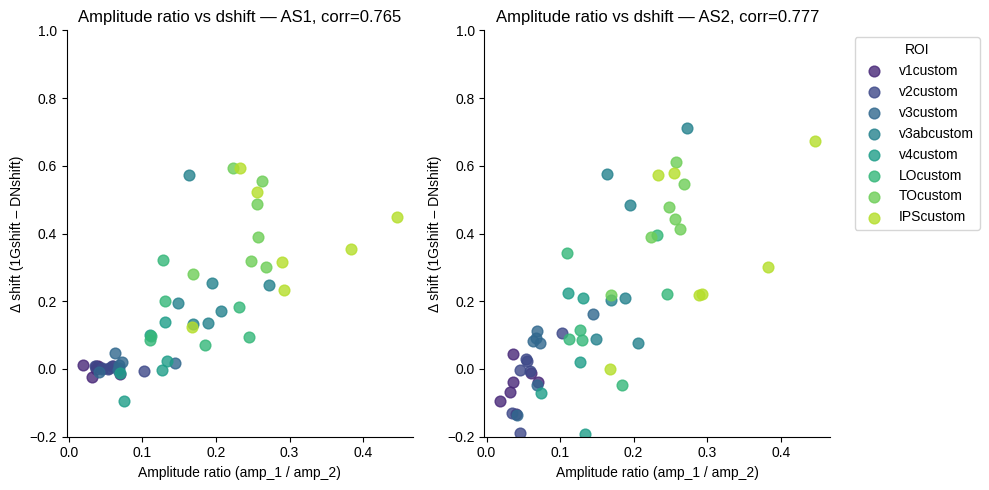

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a colour map for ROIs
palette = sns.color_palette("viridis", len(roi_list[1:]))
roi_colors = dict(zip(roi_list[1:], palette))


fig, axs = plt.subplots(1,2, figsize=(10,5))

for iT,task in enumerate(['AS1', 'AS2']):
    df = mparcorr_pd[task]
    tcorr = dag_get_corr(df['amp_ratio'], df['dshift'])
    
    for roi in roi_list[1:]:
        roi_df = df[df['roi'] == roi]
        if len(roi_df) == 0:
            continue
        axs[iT].scatter(
            roi_df['amp_ratio'], 
            roi_df['dshift'], 
            label=roi, 
            color=roi_colors[roi],
            s=60,
            alpha=0.8
        )

    # plt.axhline(1, color='gray', linestyle='--', linewidth=1)
    # plt.axvline(0, color='gray', linestyle='--', linewidth=1)
    sns.despine()
    axs[iT].set_ylabel('Δ shift (1Gshift – DNshift)')
    axs[iT].set_xlabel('Amplitude ratio (amp_1 / amp_2)')
    axs[iT].set_title(f'Amplitude ratio vs dshift — {task}, corr={tcorr:.3f}')
    
    axs[iT].set_ylim(-0.2, 1.0)
    # axs[iT].set_xlim(0.0, 0.5)
    
axs[iT].legend(title="ROI", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
fig.savefig(opj(fig_output, 'amp_ratio_dshift_corr.png'), bbox_inches='tight', dpi=150)


# SAVE

<IPython.core.display.Javascript object>